# Exercise 6 preprocessing

Same idea as exercise 4/5: load the NASA exoplanet data, remove rows with missing values, then log-transform the physical variables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data_file = "PS_2026.05.15_08.06.21.csv"
planets = pd.read_csv(data_file, comment="#")

planets.head()

,loc_rowid,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,1,11 Com b,11 Com,0,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-05-14,2008-01,2014-05-14
1,2,11 Com b,11 Com,1,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-12,2023-09-19
2,3,11 Com b,11 Com,0,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-07-23,2011-08,2014-07-23
3,4,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06
4,5,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2009-10,2014-05-14


In [2]:
# Feature columns:
# pl_rade    = planet radius [Earth radii]
# pl_masse   = planet mass [Earth masses]
# pl_dens    = planet density [g/cm^3]
# pl_orbsmax = orbital distance / semi-major axis [au]

feature_columns = ["pl_rade", "pl_masse", "pl_dens", "pl_orbsmax"]

sample_a = planets[feature_columns].apply(pd.to_numeric, errors="coerce")
sample_a = sample_a.dropna()
sample_a = sample_a[(sample_a > 0).all(axis=1)]
sample_a = sample_a.to_numpy()

print("number of planets in sample_a:", len(sample_a))

number of planets in sample_a: 2121


In [3]:
# sample_a[:,0] = planet radius
# sample_a[:,1] = planet mass
# sample_a[:,2] = planet density
# sample_a[:,3] = orbital distance

planet_r = sample_a[:, 0].copy()
planet_m = sample_a[:, 1].copy()
planet_density = sample_a[:, 2].copy()
orbital_distance = sample_a[:, 3].copy()

# log10 transformation, same idea as sheet 5
log_planet_r = np.log10(planet_r)
log_planet_m = np.log10(planet_m)
log_planet_density = np.log10(planet_density)
log_orbital_distance = np.log10(orbital_distance)

log_sample_a = np.column_stack((
    log_planet_r,
    log_planet_m,
    log_planet_density,
    log_orbital_distance
))

# Final D-dimensional feature space: D = 4
X = log_sample_a.copy()

print("feature-space dimension D:", X.shape[1])

feature-space dimension D: 4


## Transformation choice

I use a logarithmic transformation for radius, mass, density, and orbital distance because these quantities are positive and span very large ranges. The log transform compresses the scale, reduces skewness, and stops very large planets or very wide orbits from dominating the feature space.

Density is useful because it contains information about composition, but it is correlated with mass and radius.

## Gaussian mixture models

Start by fitting two Gaussian components to each 2D combination of the four log-transformed variables.

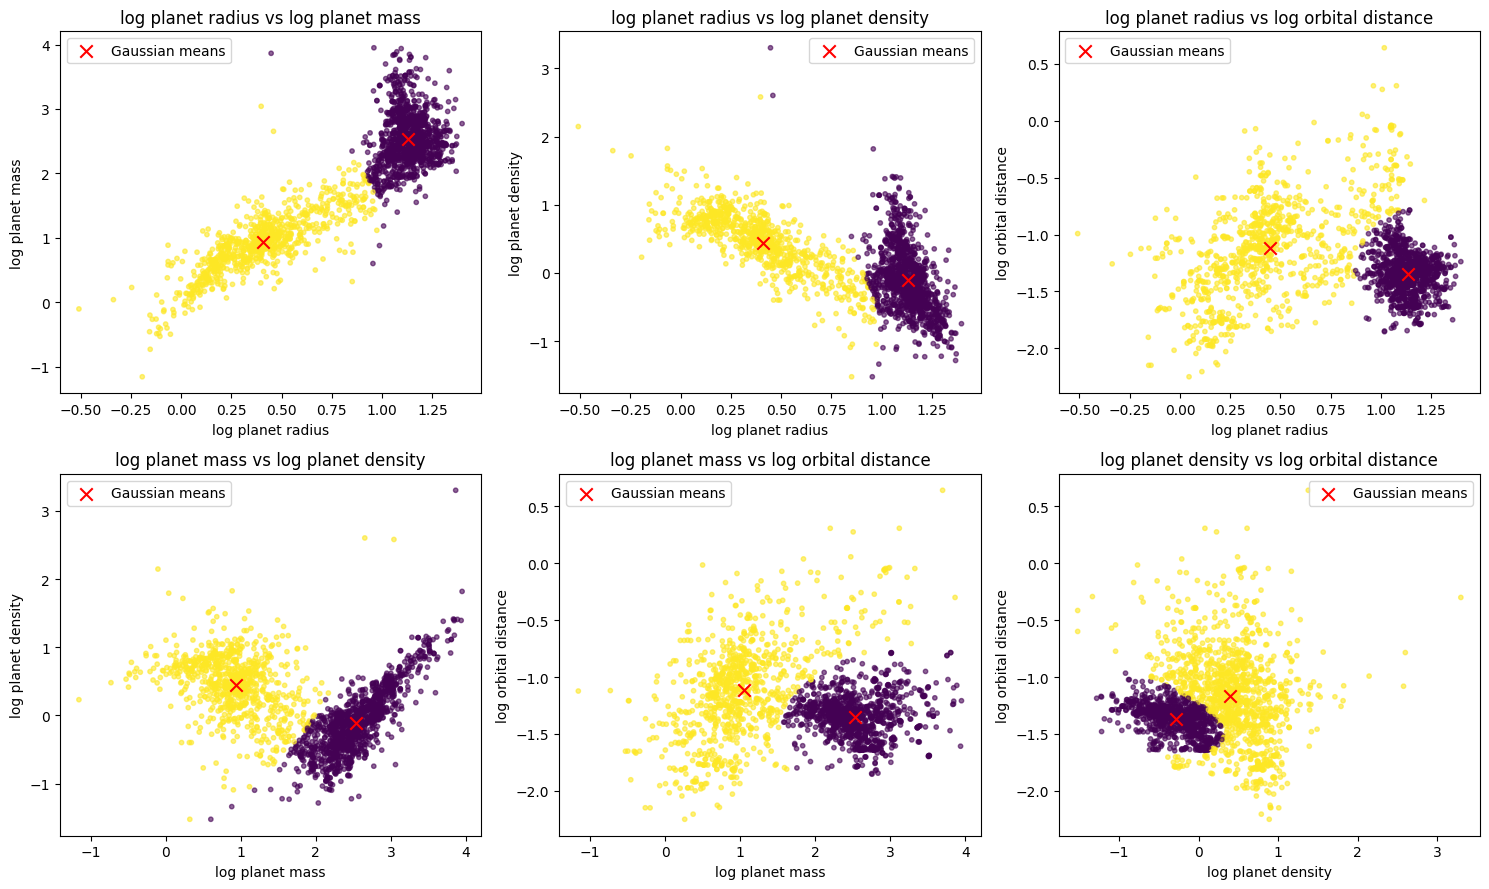

In [4]:
from itertools import combinations
from sklearn.mixture import GaussianMixture


feature_names = [
    "log planet radius",
    "log planet mass",
    "log planet density",
    "log orbital distance"
]

n_components = 2

fig, axs = plt.subplots(2, 3, figsize=(15, 9))
axs = axs.ravel()

for ax, (i, j) in zip(axs, combinations(range(4), 2)):
    X_pair = log_sample_a[:, [i, j]]

    gmm = GaussianMixture(n_components=n_components, random_state=42)
    labels = gmm.fit_predict(X_pair)

    ax.scatter(
        X_pair[:, 0],
        X_pair[:, 1],
        c=labels,
        s=10,
        alpha=0.6
    )

    ax.scatter(
        gmm.means_[:, 0],
        gmm.means_[:, 1],
        c="red",
        marker="x",
        s=80,
        label="Gaussian means"
    )

    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    ax.set_title(f"{feature_names[i]} vs {feature_names[j]}")
    ax.legend()

plt.tight_layout()
plt.show()